# Figure 3 |  Global patterns and regional examples of mangrove expansion consisting of expansion and regeneration

- Expansion means mangroves gain from new area that not occupied by mangroves in 1980s.
- Regeneration means mangroves occur back in their historical areas, compared to 1980s.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
import palettable
from tqdm import tqdm
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot
from geemap import cartoee as cee
import geemap

import ee
ee.Authenticate()
ee.Initialize()

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'


Successfully saved authorization token.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [4]:
# Spatially joining expansion and regeneration results with grids by grid ID

os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
df_expansion = pd.read_csv('Code_Data/ByGrid_Expansion1023.csv')
df_regeneration = pd.read_csv('Code_Data/ByGrid_Regeneration1023.csv')

gdf_grids = gpd.read_file('Code_Data/Grids_1degree.shp') # Read the grid shapefile
gdf_grids = gdf_grids[['ID','geometry']] # Select the columns we need
gdf_expansion = gdf_grids.merge(df_expansion, left_on='ID', right_on='Region', how='left')
gdf_regeneration = gdf_grids.merge(df_regeneration, left_on='ID', right_on='Region', how='left')

gdf_expansion.dropna(inplace=True)  # Drop rows where geometry is NaN
gdf_regeneration.dropna(inplace=True)  # Drop rows where geometry is NaN

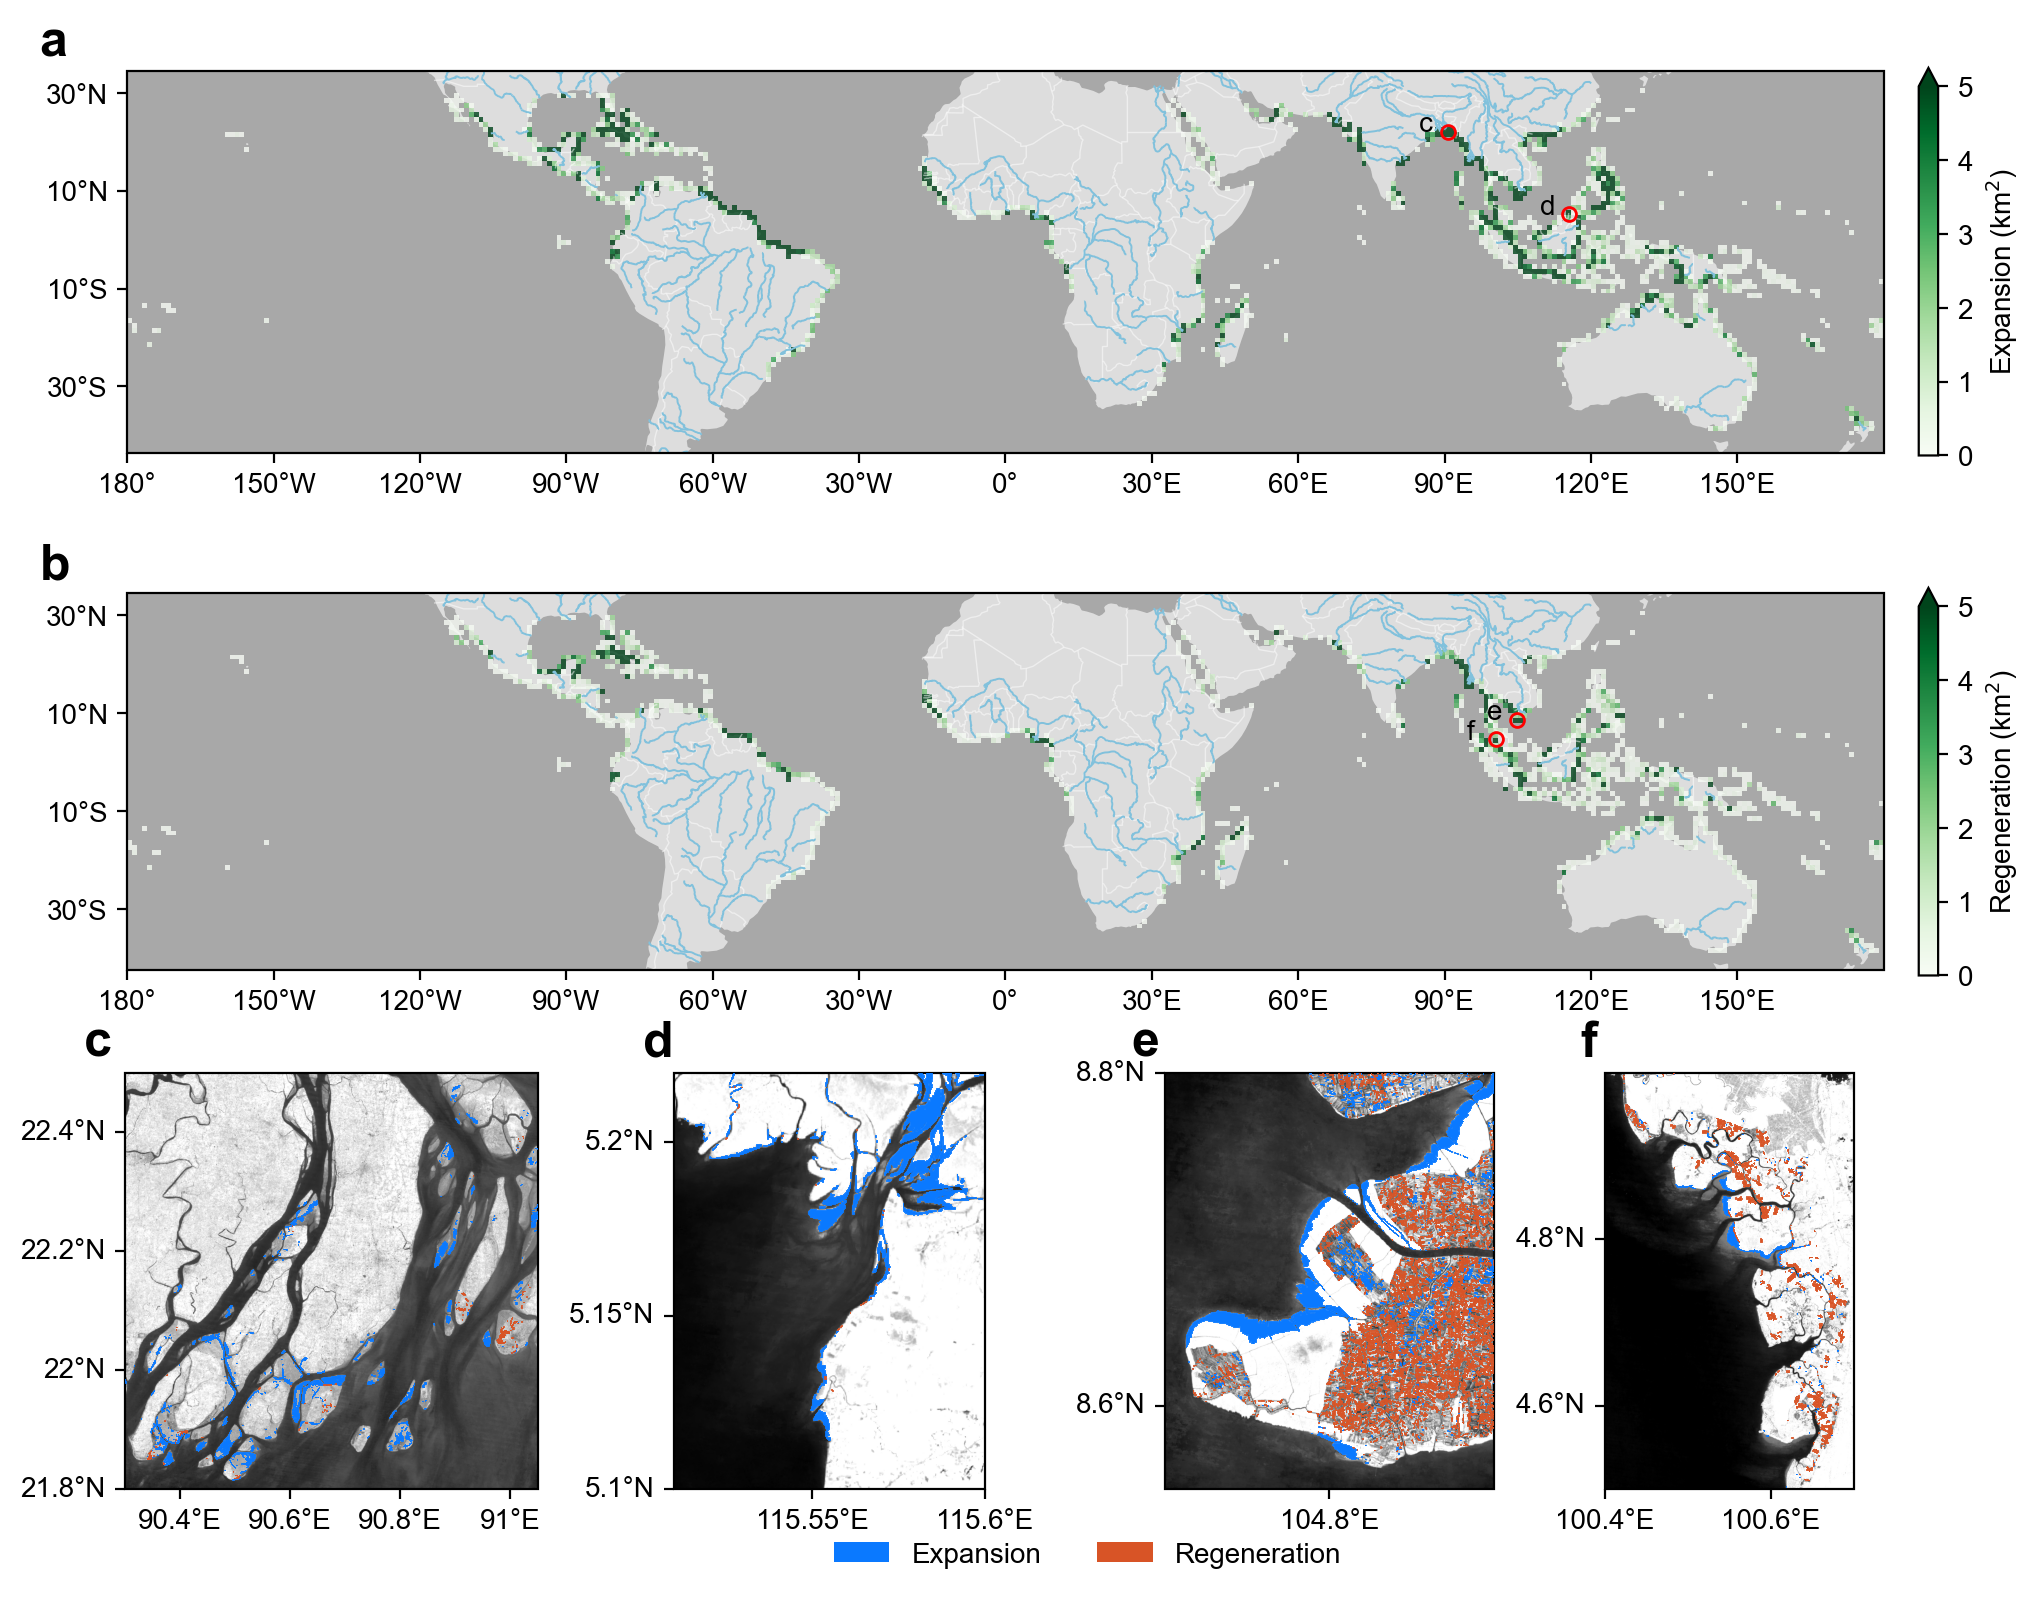

In [ ]:
import cartopy.feature as cfeature
import importlib
importlib.reload(ZhenPlot)

fig = plt.figure(figsize=(10, 5.2),constrained_layout=True)
gs = GridSpec(nrows=2, ncols=1,figure=fig)

ax_a = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax_b = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax_global = [ax_a,ax_b]
gdf_data = [gdf_expansion,gdf_regeneration]
subset_locations = [[[90.7,22.1],[115.6,5.2]],[[104.8,8.7],[100.5,4.7]]]
cb_labels = ['Expansion (km$^2$)','Regeneration (km$^2$)']
rivers = cfeature.NaturalEarthFeature(category='physical',name = 'rivers_lake_centerlines', scale='50m',facecolor = 'none')

for i,ax in enumerate(ax_global):
    ZhenPlot.add_basemap(ax,xticks=True,yticks=True,xrange=np.arange(-180,180,30),fontsize=12,ocean_color='#a8a8a8')
    gdf_data[i].plot(column='2023', ax=ax, cmap='Greens',vmin=0,vmax=5, legend=True, linewidth=0.5, alpha=0.8,legend_kwds={"label":cb_labels[i],
                                                                                                                            "shrink":0.77,
                                                                                                                            "pad":0.02,
                                                                                                                            "extend":'max'
                                                                                                                            }) # Plot grid-scale results
    ax.add_feature(rivers,edgecolor='#81c1dc',linewidth=0.7) # Add river elements
    for j,(x,y) in enumerate(subset_locations[i]):
        ax.plot(x, y, 'o', markersize=5, markerfacecolor='none',  markeredgecolor='red', transform=ccrs.PlateCarree()) # Add marks of inset panel c-f
        ax.text(x-6,y,'cdef'[i*2+j])
    ax.tick_params(axis='x',labelsize=10);ax.tick_params(axis='y',labelsize=10)
    ax.text(-0.05,1.04,'ab'[i],fontdict={'weight' : 'bold', 'size' : 18},transform=ax.transAxes)

ax_c = fig.add_axes([-0.049, -0.43, 0.4, 0.4],projection=ccrs.PlateCarree())
ax_d = fig.add_axes([0.2, -0.43, 0.4, 0.4],projection=ccrs.PlateCarree())
ax_e = fig.add_axes([0.45, -0.43, 0.4, 0.4],projection=ccrs.PlateCarree())
ax_f = fig.add_axes([0.65, -0.43, 0.4, 0.4],projection=ccrs.PlateCarree())
ax_lowerrow = [ax_c,ax_d,ax_e,ax_f]
locs = [[90.30,91.05,21.8,22.5],[115.51,115.6,5.1,5.22],[104.7,104.9,8.55,8.8],[100.4,100.7,4.5,5]] # Inset locations
shp_expansion = gpd.read_file('Code_Data/Expansion1023.shp').to_crs(epsg=4326)
shp_regeneration = gpd.read_file('Code_Data/Regeneration1023.shp').to_crs(epsg=4326)
colors_reclass = ['#0a79ff',"#d85426"]
for i,ax in enumerate(ax_lowerrow):
    if i != 1:
        interval = 0.2
    else:
        interval = 0.05
    ZhenPlot.plot_landsat(ax,'2023-01-01','2023-12-31',locs[i],
                    vis_params={'bands': ['nir'],'min': 0.0,'max': 0.3,'palette':['black','white']},
                    interval=interval,zorder=2)
    shp_expansion.cx[locs[i][0]:locs[i][1], locs[i][2]:locs[i][3]].plot(ax=ax,facecolor=colors_reclass[0],edgecolor=colors_reclass[0],linewidth=0.3,zorder=3)
    shp_regeneration.cx[locs[i][0]:locs[i][1], locs[i][2]:locs[i][3]].plot(ax=ax,facecolor=colors_reclass[1],edgecolor=colors_reclass[1],linewidth=0.3,zorder=3)
    ax.set_extent(locs[i], crs=ccrs.PlateCarree())
    ax.text(-0.1,1.04,'cdef'[i],fontdict={'weight' : 'bold', 'size' : 18},transform=ax.transAxes)

labels = ['Expansion','Regeneration']
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_reclass[i], label=str(labels[i])) for i in range(len(colors_reclass))]
ax.legend(handles=legend_elements,ncol=2, loc='lower left', frameon=False, fontsize=10,bbox_to_anchor=(-3.2, -0.25))

plt.savefig(r"Figures/Expansion&Regeneration.png", dpi=500, format='png', bbox_inches='tight')
plt.savefig(r"Figures/Expansion&Regeneration.svg", dpi=500, format='svg', bbox_inches='tight')
    # break